#  Baseline


## Setup

In [49]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "/Users/lin_/Solar_Prediction")   # so `src` is importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from src.helper.data_preprocessing import load_all_zones
from src.helper.models import build_model
from src.helper.params import get_params   # hyperparameters live in configs/model_params.yaml
from src.helper.backtest import WalkForward, time_split, tail_val_split   # splitting + backtest

plt.rcParams["figure.figsize"] = (11, 4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load data

In [50]:
# 12 raw predictors
NWP_VARS = ["VAR78","VAR79","VAR134","VAR157","VAR164","VAR165",
            "VAR166","VAR167","VAR169","VAR175","VAR178","VAR228"]

zones, df = load_all_zones(NWP_VARS)
df["POWER"] = df["POWER"].clip(0, 1)         # fix the lone 1.004 overshoot
df["ZONE"]  = df["ZONE"].astype("category")  # treat plant id as categorical, not numeric
df["hour"]  = df.ts.dt.hour                  # helper cols for the climatology baseline (not model features)
df["month"] = df.ts.dt.month

FEATURES = NWP_VARS + ["ZONE"]
TARGET   = "POWER"
print(df.shape, "|", len(FEATURES), "features")

(59112, 17) | 13 features


## 3. Train / validation / test split (time-based)

split train/test: 70/30

In [51]:
# Time-based split (from src.helper.backtest): 70/30 trainval/test, then 85/15 within trainval
trainval, test = time_split(df, (0.70, 0.30), time_col="ts")
train, val     = time_split(trainval, (0.85, 0.15), time_col="ts")

print(f"train: {train.shape[0]:>6}  (< {val.ts.min().date()})")
print(f"val  : {val.shape[0]:>6}  ({val.ts.min().date()} .. {test.ts.min().date()})")
print(f"test : {test.shape[0]:>6}  (>= {test.ts.min().date()})")

train:  35169  (< 2013-08-02)
val  :   6207  (2013-08-02 .. 2013-10-27)
test :  17736  (>= 2013-10-27)


## 4. Train XGBoost

In [52]:
# Build an XGBoost forecaster; hyperparameters come from configs/model_params.yaml
model = build_model("xgboost", **get_params("xgboost_tuned"))

# eval_set / verbose pass straight through to the underlying XGBRegressor
model.fit(
    train[FEATURES], train[TARGET],
    eval_set=[(train[FEATURES], train[TARGET]), (val[FEATURES], val[TARGET])],
    verbose=50,
)
xgb_model = model.estimator          # underlying XGBRegressor, for xgb-specific inspection
print("best_iteration:", xgb_model.best_iteration)

[0]	validation_0-rmse:0.26649	validation_1-rmse:0.28016
[50]	validation_0-rmse:0.15003	validation_1-rmse:0.16634
[100]	validation_0-rmse:0.11579	validation_1-rmse:0.13419
[150]	validation_0-rmse:0.10508	validation_1-rmse:0.12645
[200]	validation_0-rmse:0.09960	validation_1-rmse:0.12348
[250]	validation_0-rmse:0.09588	validation_1-rmse:0.12136
[300]	validation_0-rmse:0.09363	validation_1-rmse:0.12021
[350]	validation_0-rmse:0.09178	validation_1-rmse:0.11937
[400]	validation_0-rmse:0.08998	validation_1-rmse:0.11861
[450]	validation_0-rmse:0.08838	validation_1-rmse:0.11796
[482]	validation_0-rmse:0.08746	validation_1-rmse:0.11760
best_iteration: 477


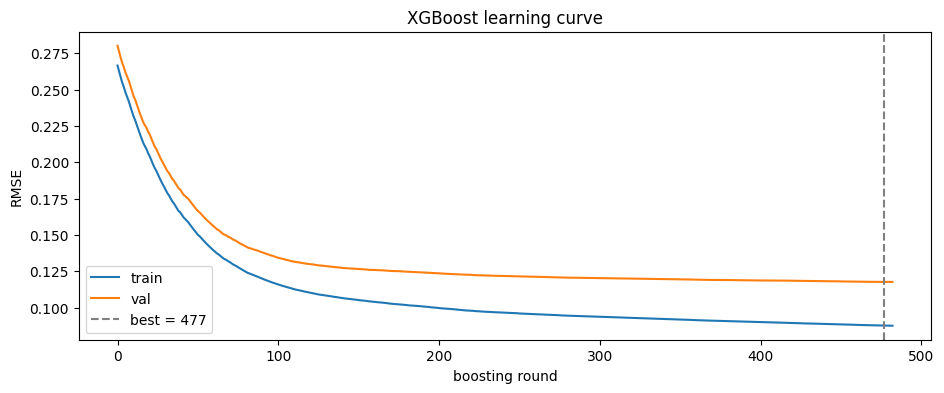

In [53]:
# Learning curve: train vs validation RMSE over boosting rounds
res = xgb_model.evals_result()
plt.plot(res["validation_0"]["rmse"], label="train")
plt.plot(res["validation_1"]["rmse"], label="val")
plt.axvline(xgb_model.best_iteration, ls="--", c="gray", label=f"best = {xgb_model.best_iteration}")
plt.xlabel("boosting round"); plt.ylabel("RMSE"); plt.legend()
plt.title("XGBoost learning curve"); plt.show()

## 5. Evaluate

Predictions clipped to `[0,1]`, compared against a **(zone, month, hour) climatology** baseline.

In [54]:
pred = np.clip(model.predict(test[FEATURES]), 0, 1)

# Climatology baseline: mean POWER per (zone, month, hour) learned on train
clim = train.groupby(["ZONE","month","hour"])[TARGET].mean()
base = (test.merge(clim.rename("clim"), on=["ZONE","month","hour"], how="left")["clim"]
            .fillna(train[TARGET].mean()).values)

rmse = root_mean_squared_error(test[TARGET], pred)
mae  = mean_absolute_error(test[TARGET], pred)
print(f"XGBoost      RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"Climatology  RMSE={root_mean_squared_error(test[TARGET], base):.4f}")
print(f"Improvement over climatology: {(1 - rmse/root_mean_squared_error(test[TARGET], base))*100:.1f}%\n")

test_ = test.assign(pred=pred)
print("Per-zone RMSE:")
print(test_.groupby("ZONE").apply(lambda g: root_mean_squared_error(g[TARGET], g["pred"])).round(4))

XGBoost      RMSE=0.1021  MAE=0.0590
Climatology  RMSE=0.1217
Improvement over climatology: 16.1%

Per-zone RMSE:
ZONE
1    0.0986
2    0.1065
3    0.1012
dtype: float64


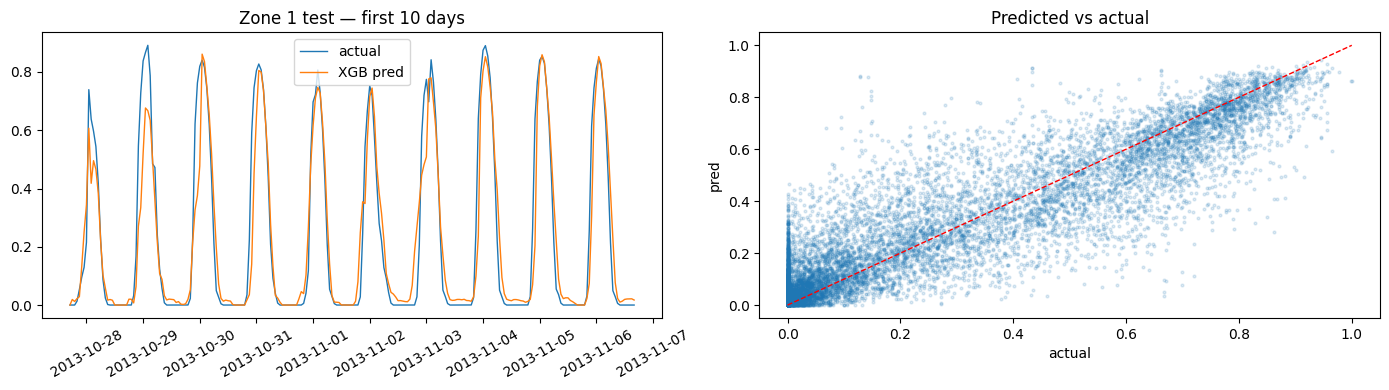

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# actual vs predicted, first 10 days of Zone 1 test
s = test_[test_.ZONE == 1].sort_values("ts").head(24*10)
ax[0].plot(s.ts, s[TARGET], label="actual", lw=1)
ax[0].plot(s.ts, s["pred"], label="XGB pred", lw=1)
ax[0].set_title("Zone 1 test — first 10 days"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)

# predicted vs actual scatter
ax[1].scatter(test_[TARGET], test_["pred"], s=4, alpha=0.15)
ax[1].plot([0,1],[0,1],"r--",lw=1); ax[1].set_xlabel("actual"); ax[1].set_ylabel("pred")
ax[1].set_title("Predicted vs actual")
plt.tight_layout(); plt.show()

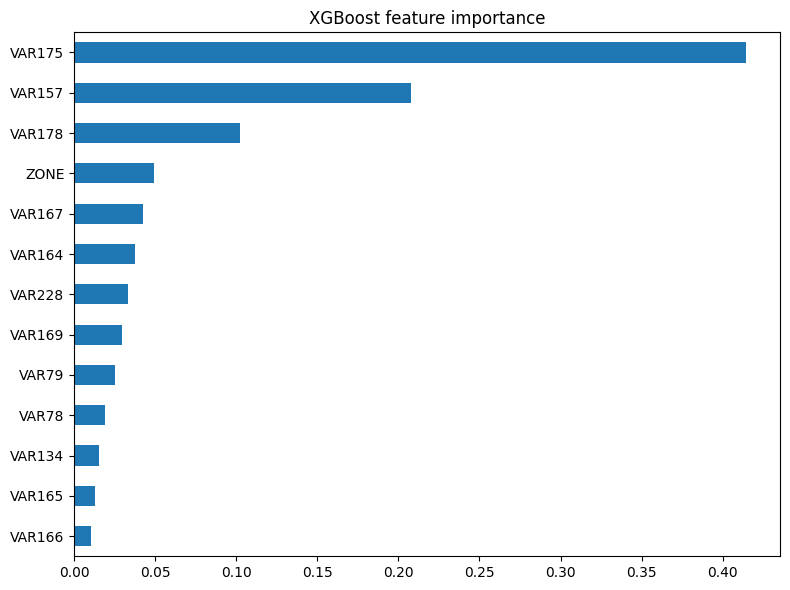

In [56]:
# Feature importance (gain)
imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(figsize=(8, 6), title="XGBoost feature importance"); plt.tight_layout(); plt.show()

0:[VAR175<5934580] yes=1,no=2,missing=2
	1:[VAR157<59.9147186] yes=3,no=4,missing=4
		3:[VAR175<4518849] yes=7,no=8,missing=8
			7:[VAR157<49.1800385] yes=15,no=16,missing=16
				15:[VAR175<3498683] yes=31,no=32,missing=32
					31:leaf=0.0115217287
					32:leaf=0.00981919747
				16:[VAR164<0.681793213] yes=33,no=34,missing=34
					33:leaf=0.00959374569
					34:leaf=0.00699724536
			8:[VAR167<289.907959] yes=17,no=18,missing=18
				17:[VAR175<5221878] yes=35,no=36,missing=36
					35:leaf=0.00597410975
					36:leaf=0.00316062081
				18:[VAR79<0.0228023529] yes=37,no=38,missing=38
					37:leaf=0.00869001076
					38:leaf=0.00553855766
		4:[VAR79<0.017838873] yes=9,no=10,missing=10
			9:[VAR175<4028021] yes=19,no=20,missing=20
				19:[VAR78<0.0368652344] yes=39,no=40,missing=40
					39:leaf=0.00791710522
					40:leaf=0.00439485721
				20:[VAR157<64.3851013] yes=41,no=42,missing=42
					41:leaf=0.00402681762
					42:leaf=0.00226174784
			10:[VAR157<74.6946564] yes=21,no=22,missing=22
				21:

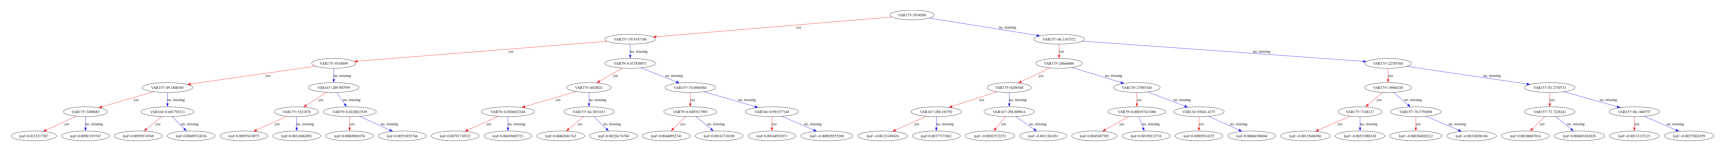

In [57]:
# Inspect one tree's split conditions
tree_idx = 0
booster  = xgb_model.get_booster()

# 1) Text rules (always works): "[feature<threshold] yes=.. no=.." ; leaf = output value
print(booster.get_dump(with_stats=False)[tree_idx])

# 2) Diagram (needs the graphviz 'dot' binary -> `brew install graphviz`)
try:
    fig, ax = plt.subplots(figsize=(22, 10))
    xgb.plot_tree(xgb_model, tree_idx=tree_idx, ax=ax); plt.show()
except Exception as e:
    print("plot_tree needs graphviz 'dot'. Install: brew install graphviz\n", e)

## 6. Model comparison — XGBoost vs LightGBM vs RandomForest

All three built via `build_model`, same features and same fixed budget (no early stopping)
for a fair comparison. `ZONE` is encoded as integer codes so RandomForest accepts it too.

In [58]:
# ZONE as integer codes so every model (incl. RandomForest) accepts the same X
Xtr = train[FEATURES].assign(ZONE=train.ZONE.cat.codes)
Xte = test[FEATURES].assign(ZONE=test.ZONE.cat.codes)
ytr, yte = train[TARGET], test[TARGET]

# Presets live in configs/model_params.yaml — tune there, not here
rows = []
for name in ["xgboost", "lightgbm", "rf"]:
    m = build_model(name, **get_params(name)).fit(Xtr, ytr)
    p = np.clip(m.predict(Xte), 0, 1)
    rows.append({"model": name,
                 "RMSE": root_mean_squared_error(yte, p),
                 "MAE":  mean_absolute_error(yte, p)})

comparison = pd.DataFrame(rows).set_index("model").sort_values("RMSE").round(4)
comparison

,RMSE,MAE
model,,
rf,0.0998,0.0540
xgboost,0.1003,0.0573
lightgbm,0.1008,0.0583


## 7. Walk-forward backtest

- use `WalkForward` (from `src/helper/backtest.py`) to have expanding train window and one month test

- train & test 70/30

- inside train: train/val: 85/15

In [59]:
VAL_FRAC = 0.15   # tail of each fold's train reserved for early-stopping validation

wf = WalkForward.gefcom_monthly(warmup_months=13)   # expanding window, one calendar month per test fold

records, preds = [], []
for tr, te, fold in wf.split(df, time_col="ts"):
    inner, val = tail_val_split(tr, frac=VAL_FRAC)   # tail-of-train val, always before the test month
    m = build_model("xgboost", **get_params("xgboost_tuned"))
    m.fit(
        inner[FEATURES], inner[TARGET],
        eval_set=[(val[FEATURES], val[TARGET])],   # early stopping on the tail-of-train val
        verbose=False,
    )
    p = np.clip(m.predict(te[FEATURES]), 0, 1)
    records.append({
        "fold": fold.id,
        "test_start": fold.test_start, "test_end": fold.test_end,
        "n_train": len(inner), "n_val": len(val), "n_test": len(te),
        "best_iter": m.estimator.best_iteration,
        "RMSE": root_mean_squared_error(te[TARGET], p),
        "MAE":  mean_absolute_error(te[TARGET], p),
    })
    preds.append(te.assign(pred=p, fold=fold.id))

bt  = pd.DataFrame(records)
oof = pd.concat(preds, ignore_index=True)   # out-of-fold predictions, pooled across all test months

print(bt.drop(columns=["test_end"]).round(4).to_string(index=False))
print(f"\nAcross {len(bt)} folds:  RMSE = {bt.RMSE.mean():.4f} ± {bt.RMSE.std():.4f}   "
      f"MAE = {bt.MAE.mean():.4f} ± {bt.MAE.std():.4f}")
print(f"Pooled out-of-fold:  RMSE = {root_mean_squared_error(oof[TARGET], oof['pred']):.4f}  "
      f"MAE = {mean_absolute_error(oof[TARGET], oof['pred']):.4f}")

 fold          test_start  n_train  n_val  n_test  best_iter   RMSE    MAE
    0 2013-05-01 01:00:00    24174   4266    2232        305 0.1003 0.0577
    1 2013-06-01 01:00:00    26070   4602    2160        195 0.0922 0.0523
    2 2013-07-01 01:00:00    27906   4926    2232        231 0.1038 0.0536
    3 2013-08-01 01:00:00    29802   5262    2232        119 0.1225 0.0756
    4 2013-09-01 01:00:00    31701   5595    2160        302 0.1112 0.0635
    5 2013-10-01 01:00:00    33537   5919    2232        597 0.1238 0.0727
    6 2013-11-01 01:00:00    35433   6255    2160        600 0.1036 0.0611
    7 2013-12-01 01:00:00    37269   6579    2232        567 0.1013 0.0578
    8 2014-01-01 01:00:00    39168   6912    2232        547 0.1257 0.0787
    9 2014-02-01 01:00:00    41064   7248    2016        684 0.1128 0.0674
   10 2014-03-01 01:00:00    42777   7551    2232        392 0.0958 0.0564
   11 2014-04-01 01:00:00    44676   7884    2160        280 0.0924 0.0545
   12 2014-05-01 01:00:00

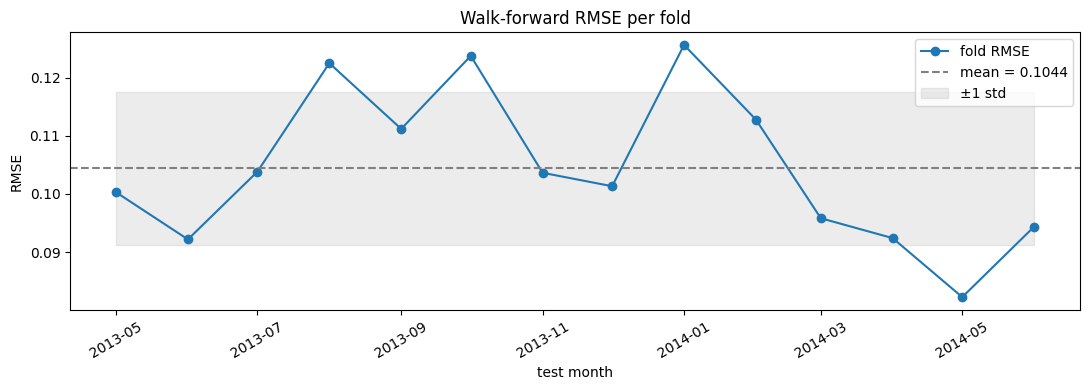

In [61]:
# RMSE per monthly test fold, with the mean line for reference
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(bt.test_start, bt.RMSE, marker="o", label="fold RMSE")
ax.axhline(bt.RMSE.mean(), ls="--", c="gray", label=f"mean = {bt.RMSE.mean():.4f}")
ax.fill_between(bt.test_start, bt.RMSE.mean() - bt.RMSE.std(), bt.RMSE.mean() + bt.RMSE.std(),
                color="gray", alpha=0.15, label="±1 std")
ax.set_xlabel("test month"); ax.set_ylabel("RMSE"); ax.set_title("Walk-forward RMSE per fold")
ax.legend(); ax.tick_params(axis="x", rotation=30); plt.tight_layout(); plt.show()